# 09 — Interpretability, geometry, topology, and brain-model alignment

I quantify the geometry of latent trajectories and include optional DNN-to-brain alignment. I keep DNN alignment conditional on available movie templates and internet access for pretrained weights.

In [2]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from v1_manifold.config import load_config, get_paths, set_global_seed
from v1_manifold.visualization import set_publication_style, save_figure
from v1_manifold.utils import save_table

cfg = load_config(ROOT / "configs" / "default.yaml")
cfg["paths"]["root"] = str(ROOT)
paths = get_paths(cfg)
set_global_seed(cfg["project"]["random_seed"])
set_publication_style()
print(f"Project root: {ROOT}")

Project root: c:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies


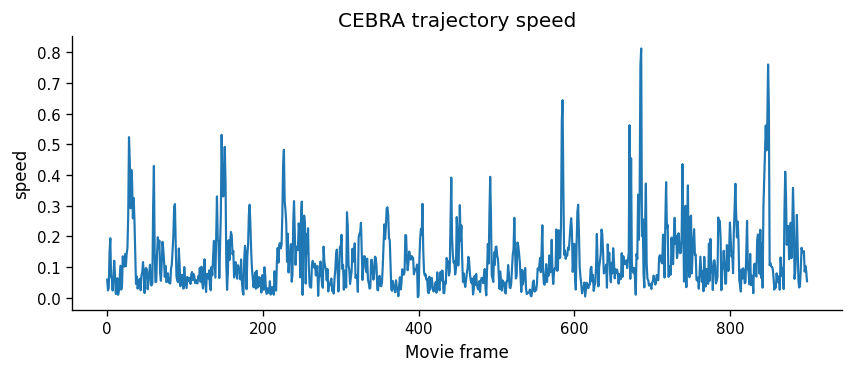

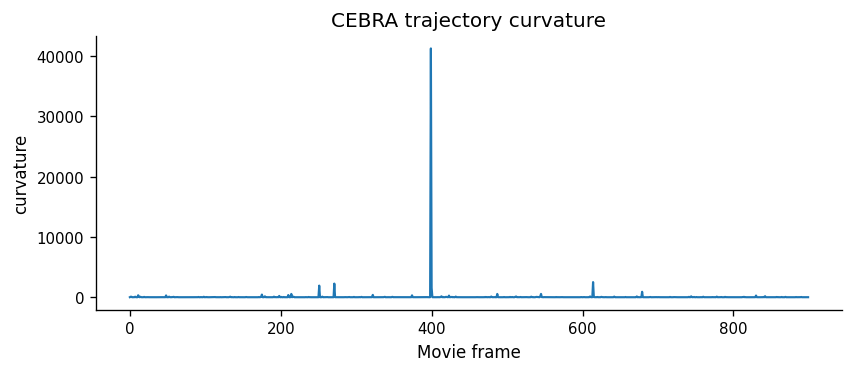

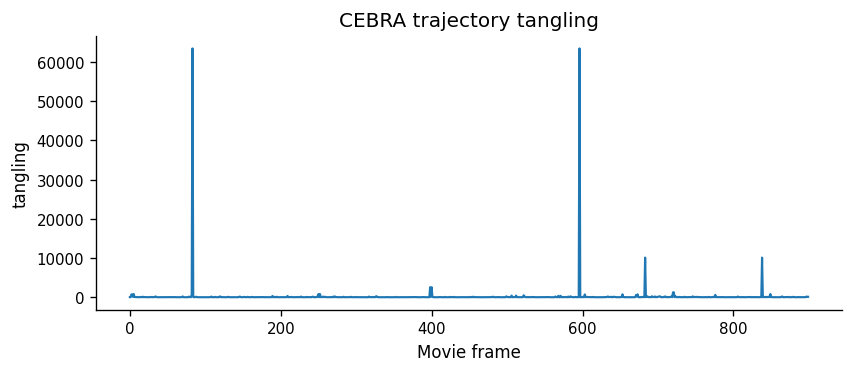

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from v1_manifold.geometry import trajectory_speed, trajectory_curvature, trajectory_tangling, persistent_homology
from v1_manifold.visualization import plot_geometry_timeseries

emb_files = sorted(paths.processed_dir.glob("session_*_embeddings.npz"))
emb_path = emb_files[0]
session_id = emb_path.name.split("_")[1]
emb = np.load(emb_path)
embedding_name = "cebra" if "cebra" in emb.files else "umap"
Z = emb[embedding_name]

speed = trajectory_speed(Z)
curvature = trajectory_curvature(Z)
tangling = trajectory_tangling(Z)
geom_ts = pd.DataFrame({"movie_frame": np.arange(len(speed)), "speed": speed, "curvature": curvature, "tangling": tangling})
save_table(geom_ts, paths.tables_dir / f"09_geometry_timeseries_{embedding_name}_session_{session_id}.csv")
for col in ["speed", "curvature", "tangling"]:
    fig = plot_geometry_timeseries(geom_ts[col].to_numpy(), ylabel=col, title=f"{embedding_name.upper()} trajectory {col}")
    save_figure(fig, paths.figures_dir / f"09_{embedding_name}_{col}_timeseries.png")
    plt.show()

In [4]:
# ---------------------------------------------------------------------
# Robust geometry summaries and publication-ready geometry plots
# ---------------------------------------------------------------------
def robust_geometry_summary(values, name):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]

    return {
        "metric": name,
        "n_points": int(len(values)),
        "n_finite": int(len(finite)),
        "mean": float(np.mean(finite)),
        "median": float(np.median(finite)),
        "std": float(np.std(finite)),
        "p90": float(np.percentile(finite, 90)),
        "p95": float(np.percentile(finite, 95)),
        "p99": float(np.percentile(finite, 99)),
        "max": float(np.max(finite)),
    }

geometry_summary = pd.DataFrame([
    robust_geometry_summary(speed, "speed"),
    robust_geometry_summary(curvature, "curvature"),
    robust_geometry_summary(tangling, "tangling"),
])

save_table(
    geometry_summary,
    paths.tables_dir / f"09_robust_geometry_summary_{embedding_name}_session_{session_id}.csv",
)

display(geometry_summary)

,metric,n_points,n_finite,mean,median,std,p90,p95,p99,max
0,speed,900,900,0.120083,0.090647,0.104150,0.244333,0.305053,0.531326,0.813125
1,curvature,900,900,71.560742,3.959345,1382.216015,31.215597,70.925909,443.513923,41273.015297
2,tangling,900,900,213.606181,13.679763,3024.368355,100.876553,181.594857,816.913173,63416.927433


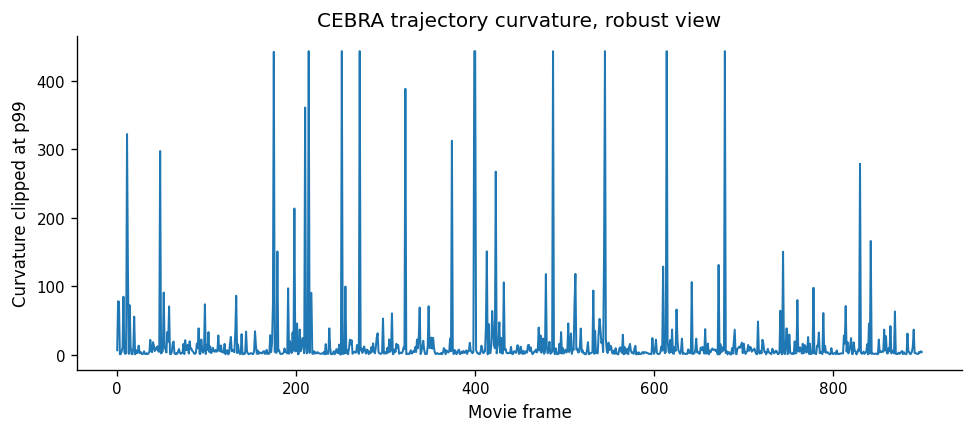

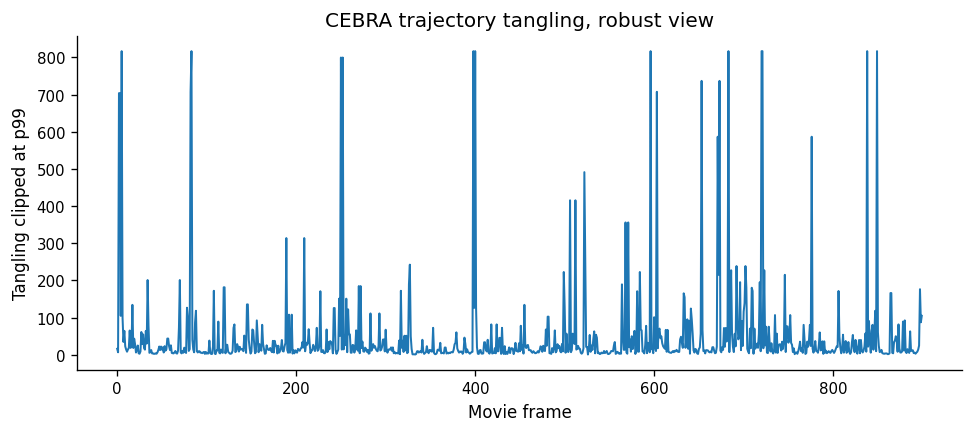

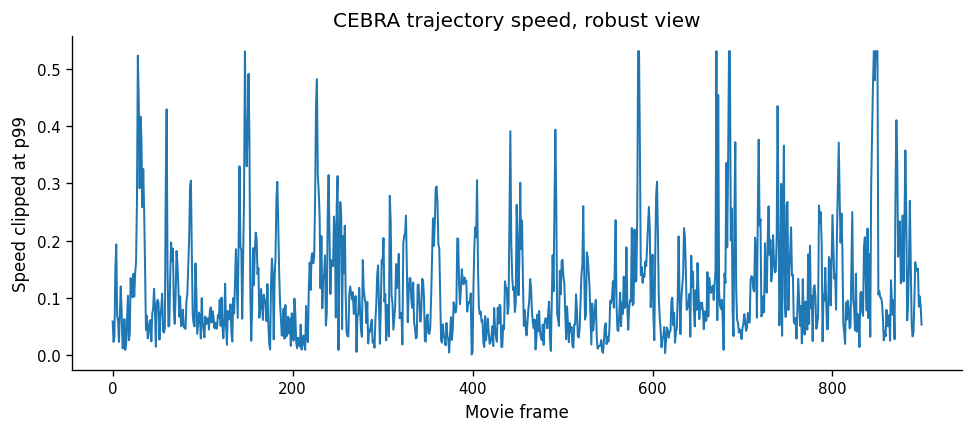

Curvature p99 clipping value: 443.513922595995
Tangling p99 clipping value: 816.913173111094
Speed p99 clipping value: 0.5313263165817765


In [5]:
# ---------------------------------------------------------------------
# Robust clipped plots: these are easier to interpret than raw spike plots
# ---------------------------------------------------------------------
def plot_clipped_timeseries(values, ylabel, title, filename, clip_percentile=99):
    values = np.asarray(values, dtype=float)
    finite = values[np.isfinite(values)]

    upper = np.percentile(finite, clip_percentile)
    clipped = np.clip(values, None, upper)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(np.arange(len(clipped)), clipped, linewidth=1.2)

    ax.set_xlabel("Movie frame")
    ax.set_ylabel(f"{ylabel} clipped at p{clip_percentile}")
    ax.set_title(title)

    save_figure(fig, paths.figures_dir / filename)
    plt.show()

    return upper

curvature_clip = plot_clipped_timeseries(
    curvature,
    ylabel="Curvature",
    title=f"{embedding_name.upper()} trajectory curvature, robust view",
    filename=f"09_{embedding_name}_curvature_timeseries_clipped_p99.png",
    clip_percentile=99,
)

tangling_clip = plot_clipped_timeseries(
    tangling,
    ylabel="Tangling",
    title=f"{embedding_name.upper()} trajectory tangling, robust view",
    filename=f"09_{embedding_name}_tangling_timeseries_clipped_p99.png",
    clip_percentile=99,
)

speed_clip = plot_clipped_timeseries(
    speed,
    ylabel="Speed",
    title=f"{embedding_name.upper()} trajectory speed, robust view",
    filename=f"09_{embedding_name}_speed_timeseries_clipped_p99.png",
    clip_percentile=99,
)

print("Curvature p99 clipping value:", curvature_clip)
print("Tangling p99 clipping value:", tangling_clip)
print("Speed p99 clipping value:", speed_clip)

In [6]:
# ---------------------------------------------------------------------
# Identify movie frames with extreme geometry values
# ---------------------------------------------------------------------
def top_geometry_events(values, metric_name, n=15):
    values = np.asarray(values, dtype=float)
    order = np.argsort(values)[::-1]

    rows = []
    for idx in order[:n]:
        rows.append({
            "movie_frame": int(idx),
            "metric": metric_name,
            "value": float(values[idx]),
        })

    return pd.DataFrame(rows)

extreme_events = pd.concat(
    [
        top_geometry_events(speed, "speed"),
        top_geometry_events(curvature, "curvature"),
        top_geometry_events(tangling, "tangling"),
    ],
    ignore_index=True,
)

save_table(
    extreme_events,
    paths.tables_dir / f"09_extreme_geometry_events_{embedding_name}_session_{session_id}.csv",
)

display(extreme_events)

,movie_frame,metric,value
0,686,speed,0.813125
1,849,speed,0.760739
2,685,speed,0.759705
3,585,speed,0.644228
4,850,speed,0.622875
5,584,speed,0.577257
6,848,speed,0.572561
7,671,speed,0.562405
8,846,speed,0.561483
9,147,speed,0.531022


In [ ]:
# ---------------------------------------------------------------------
# Geometry–stimulus alignment using real movie-frame features
# ---------------------------------------------------------------------
from scipy.stats import spearmanr

# Load real frame features from notebook 04
feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_real_frame_features.csv"))
if not feature_candidates:
    feature_candidates = sorted(paths.processed_dir.glob(f"session_{session_id}*_frame_features.csv"))

if not feature_candidates:
    raise FileNotFoundError("No real movie-frame feature table found. Run notebook 04 first.")

features = pd.read_csv(feature_candidates[0])

# Merge geometry time series with visual features
geom_feature_df = geom_ts.merge(features, on="movie_frame", how="inner")

# Log-transform heavy-tailed geometry metrics for robust association tests
geom_feature_df["log1p_speed"] = np.log1p(geom_feature_df["speed"])
geom_feature_df["log1p_curvature"] = np.log1p(geom_feature_df["curvature"])
geom_feature_df["log1p_tangling"] = np.log1p(geom_feature_df["tangling"])

geometry_cols = [
    "log1p_speed",
    "log1p_curvature",
    "log1p_tangling",
]

stimulus_cols = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]

stimulus_cols = [c for c in stimulus_cols if c in geom_feature_df.columns]


def circular_shift_spearman_test(x, y, n_perm=1000, min_shift=60, random_state=42):
    """
    Spearman correlation with a circular-shift null.
    This controls partly for temporal autocorrelation in natural movie frames.
    """
    rng = np.random.default_rng(random_state)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    if len(x) < 10:
        return np.nan, np.nan, np.nan, np.nan

    observed_r, _ = spearmanr(x, y)

    n = len(y)
    shifts = rng.integers(min_shift, max(min_shift + 1, n - min_shift), size=n_perm)

    null = []
    for shift in shifts:
        y_shifted = np.roll(y, int(shift))
        r, _ = spearmanr(x, y_shifted)
        null.append(r)

    null = np.asarray(null, dtype=float)
    null = null[np.isfinite(null)]

    p_value = (np.sum(np.abs(null) >= abs(observed_r)) + 1) / (len(null) + 1)

    return observed_r, p_value, float(np.mean(null)), float(np.std(null))


rows = []

for geom_col in geometry_cols:
    for stim_col in stimulus_cols:
        rho, p_shift, null_mean, null_std = circular_shift_spearman_test(
            geom_feature_df[geom_col],
            geom_feature_df[stim_col],
            n_perm=1000,
            min_shift=60,
            random_state=cfg["project"]["random_seed"],
        )

        rows.append({
            "session_id": session_id,
            "embedding": embedding_name,
            "geometry_metric": geom_col,
            "stimulus_feature": stim_col,
            "spearman_r": rho,
            "circular_shift_p": p_shift,
            "null_mean": null_mean,
            "null_std": null_std,
            "n_frames": len(geom_feature_df),
        })

geometry_stimulus_alignment = pd.DataFrame(rows)

save_table(
    geometry_stimulus_alignment,
    paths.tables_dir / f"09_geometry_stimulus_alignment_{embedding_name}_session_{session_id}.csv",
)

display(
    geometry_stimulus_alignment
    .sort_values("circular_shift_p")
)

,session_id,embedding,geometry_metric,stimulus_feature,spearman_r,circular_shift_p,null_mean,null_std,n_frames
4,500855614,cebra,log1p_speed,total_spectral_power,-0.151698,0.002997,0.009685,0.071648,900
9,500855614,cebra,log1p_curvature,total_spectral_power,0.079795,0.024975,-0.004974,0.039711,900
14,500855614,cebra,log1p_tangling,total_spectral_power,-0.107722,0.084915,0.012307,0.070343,900
5,500855614,cebra,log1p_curvature,rms_contrast,-0.045337,0.171828,0.004146,0.033549,900
8,500855614,cebra,log1p_curvature,luminance_std,-0.044301,0.184815,0.004064,0.033623,900
12,500855614,cebra,log1p_tangling,orientation_selectivity,0.088993,0.252747,-0.005423,0.079894,900
0,500855614,cebra,log1p_speed,rms_contrast,0.079552,0.387612,-0.011186,0.082547,900
3,500855614,cebra,log1p_speed,luminance_std,0.077820,0.405594,-0.011059,0.082622,900
6,500855614,cebra,log1p_curvature,spatial_frequency_centroid,0.029421,0.536464,-0.000638,0.042097,900
13,500855614,cebra,log1p_tangling,luminance_std,0.063061,0.692308,-0.012701,0.101862,900


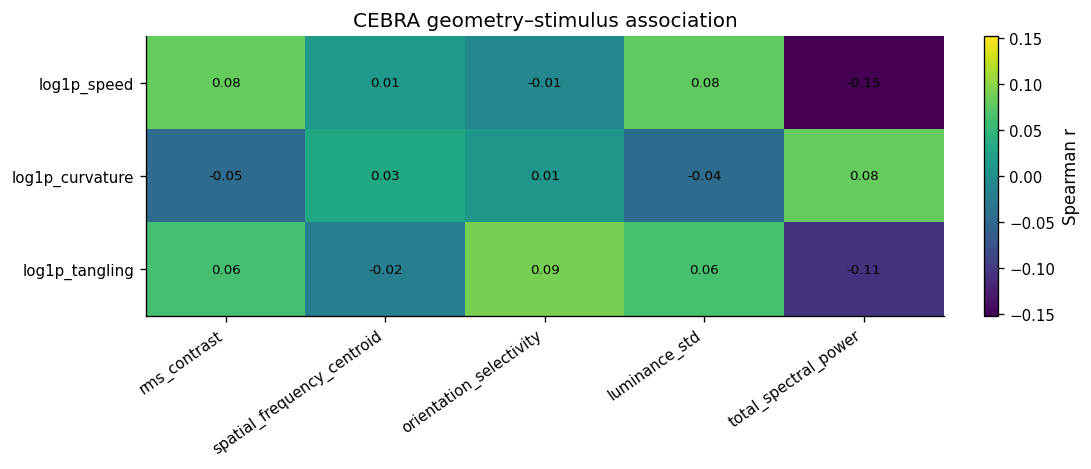

In [10]:
# ---------------------------------------------------------------------
# Heatmap of geometry–stimulus associations
# ---------------------------------------------------------------------
heatmap_df = geometry_stimulus_alignment.pivot(
    index="geometry_metric",
    columns="stimulus_feature",
    values="spearman_r",
)

# Optional: keep rows/columns in a clean scientific order
row_order = [
    "log1p_speed",
    "log1p_curvature",
    "log1p_tangling",
]
row_order = [r for r in row_order if r in heatmap_df.index]
heatmap_df = heatmap_df.loc[row_order]

col_order = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]
col_order = [c for c in col_order if c in heatmap_df.columns]
heatmap_df = heatmap_df[col_order]

values = heatmap_df.to_numpy(dtype=float)

if np.all(~np.isfinite(values)):
    raise ValueError("All geometry–stimulus association values are NaN.")

vmax = np.nanmax(np.abs(values))
vmax = max(vmax, 1e-6)

fig, ax = plt.subplots(figsize=(9, 3.8), constrained_layout=True)

im = ax.imshow(
    values,
    aspect="auto",
    vmin=-vmax,
    vmax=vmax,
)

ax.set_xticks(np.arange(heatmap_df.shape[1]))
ax.set_xticklabels(heatmap_df.columns, rotation=35, ha="right")

ax.set_yticks(np.arange(heatmap_df.shape[0]))
ax.set_yticklabels(heatmap_df.index)

ax.set_title(f"{embedding_name.upper()} geometry–stimulus association")

# Add numeric Spearman-r annotations
for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = values[i, j]
        if np.isfinite(val):
            ax.text(
                j,
                i,
                f"{val:.2f}",
                ha="center",
                va="center",
                fontsize=8,
            )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Spearman r")

# Do NOT call fig.tight_layout() here.
save_figure(
    fig,
    paths.figures_dir / f"09_geometry_stimulus_alignment_heatmap_{embedding_name}.png",
)

plt.show()

The geometry-stimulus association analysis showed weak Spearman correlations between CEBRA trajectory geometry and extracted movie-frame features. The largest absolute association was modest, with |r| ≈ 0.15. This suggests that latent trajectory speed, curvature, and tangling are not trivially explained by any single low-level visual feature such as contrast, luminance variability, orientation selectivity, spatial-frequency centroid, or total spectral power. Therefore, subsequent interpretation of extreme geometric events should be treated as exploratory and should focus on whether these events correspond to richer combinations of visual structure rather than isolated frame-level statistics.

In [9]:
# ---------------------------------------------------------------------
# Attach real movie-frame features to extreme geometry events
# ---------------------------------------------------------------------
extreme_event_features = extreme_events.merge(
    features,
    on="movie_frame",
    how="left",
)

save_table(
    extreme_event_features,
    paths.tables_dir / f"09_extreme_geometry_events_with_stimulus_features_{embedding_name}_session_{session_id}.csv",
)

display(extreme_event_features.head(30))

,movie_frame,metric,value,population_mean,population_std,population_l2_norm,n_cells,luminance_mean,luminance_std,rms_contrast,...,spatial_frequency_energy_bin_1,spatial_frequency_energy_bin_2,spatial_frequency_energy_bin_3,spatial_frequency_energy_bin_4,dominant_orientation_coarse,dominant_orientation_coarse_is_other,orientation_confidence,orientation_confidence_threshold,dominant_orientation_confident,dominant_orientation_confident_is_ambiguous
0,686,speed,0.813125,-0.016246,0.337960,4.319773,163,0.493476,0.192136,0.389353,...,0.596814,0.174729,0.055203,0.005067,bin_3,False,0.369590,0.351332,bin_3,False
1,849,speed,0.760739,0.110300,0.961062,12.350561,163,0.491675,0.185513,0.377309,...,0.660492,0.139167,0.059570,0.004350,bin_3,False,0.217339,0.351332,ambiguous,True
2,685,speed,0.759705,-0.056018,0.321630,4.168110,163,0.493528,0.192158,0.389356,...,0.596128,0.174546,0.055612,0.005143,bin_3,False,0.368813,0.351332,bin_3,False
3,585,speed,0.644228,-0.019014,0.408698,5.223551,163,0.491392,0.187051,0.380656,...,0.597769,0.168443,0.059659,0.005768,bin_3,False,0.479823,0.351332,bin_3,False
4,850,speed,0.622875,0.108906,0.905187,11.639990,163,0.491667,0.185299,0.376879,...,0.651723,0.140552,0.052144,0.003934,bin_3,False,0.198198,0.351332,ambiguous,True
5,584,speed,0.577257,0.025268,0.403650,5.163552,163,0.491423,0.186909,0.380343,...,0.593785,0.170076,0.058186,0.006291,bin_3,False,0.482557,0.351332,bin_3,False
6,848,speed,0.572561,0.116379,0.960018,12.346420,163,0.491624,0.185545,0.377412,...,0.663052,0.139685,0.064938,0.004059,bin_3,False,0.230729,0.351332,ambiguous,True
7,671,speed,0.562405,-0.049419,0.251692,3.274749,163,0.493495,0.191120,0.387278,...,0.578181,0.183759,0.063151,0.005299,bin_3,False,0.440389,0.351332,bin_3,False
8,846,speed,0.561483,0.123808,0.716357,9.281422,163,0.491968,0.185584,0.377229,...,0.642145,0.148660,0.070120,0.004301,bin_3,False,0.231991,0.351332,ambiguous,True
9,147,speed,0.531022,0.134278,0.597904,7.823660,163,0.490464,0.175792,0.358420,...,0.565255,0.274681,0.049325,0.002247,bin_4,False,0.244772,0.351332,ambiguous,True


In [11]:
# ---------------------------------------------------------------------
# Small robust save helpers
# ---------------------------------------------------------------------
def _save_table(df, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if "save_table" in globals():
        return save_table(df, path)
    df.to_csv(path, index=False)
    return path


def _save_figure(fig, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if "save_figure" in globals():
        return save_figure(fig, path)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path


# ---------------------------------------------------------------------
# Reload saved embeddings
# ---------------------------------------------------------------------
emb_files = sorted(paths.processed_dir.glob("session_*_embeddings.npz"))
if not emb_files:
    raise FileNotFoundError("No embedding file found. Run notebook 05/07 first.")

emb_path = emb_files[0]
session_id = emb_path.name.split("_")[1]

with np.load(emb_path, allow_pickle=False) as emb_file:
    emb = {k: emb_file[k] for k in emb_file.files}

embedding_name = "cebra" if "cebra" in emb else "umap"
Z = np.asarray(emb[embedding_name])

print("Session:", session_id)
print("Embedding used for notebook 09:", embedding_name)
print("Embedding shape:", Z.shape)


# ---------------------------------------------------------------------
# Reload real movie-frame features
# ---------------------------------------------------------------------
feature_candidates = sorted(
    paths.processed_dir.glob(f"session_{session_id}*_real_frame_features.csv")
)

if not feature_candidates:
    feature_candidates = sorted(
        paths.processed_dir.glob(f"session_{session_id}*_frame_features.csv")
    )

if not feature_candidates:
    raise FileNotFoundError("No frame-feature table found. Run notebook 04 first.")

features = pd.read_csv(feature_candidates[0])
print("Feature file:", feature_candidates[0])
print("Feature table shape:", features.shape)


# ---------------------------------------------------------------------
# Recompute geometry time series from the selected embedding
# ---------------------------------------------------------------------
speed = trajectory_speed(Z)
curvature = trajectory_curvature(Z)
tangling = trajectory_tangling(Z)

n = min(len(features), len(speed), len(curvature), len(tangling))

geom_ts = pd.DataFrame({
    "movie_frame": np.arange(n),
    "speed": np.asarray(speed[:n], dtype=float),
    "curvature": np.asarray(curvature[:n], dtype=float),
    "tangling": np.asarray(tangling[:n], dtype=float),
})

for col in ["speed", "curvature", "tangling"]:
    geom_ts[f"log1p_{col}"] = np.log1p(np.clip(geom_ts[col].to_numpy(), 0, None))

_save_table(
    geom_ts,
    paths.tables_dir / f"09_geometry_timeseries_{embedding_name}_session_{session_id}.csv",
)

display(geom_ts.head())

Session: 500855614
Embedding used for notebook 09: cebra
Embedding shape: (900, 3)
Feature file: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_natural_movie_one_real_frame_features.csv
Feature table shape: (900, 34)


,movie_frame,speed,curvature,tangling,log1p_speed,log1p_curvature,log1p_tangling
0,0,0.058682,6.269199,15.999419,0.057025,1.983646,2.833179
1,1,0.023086,77.816935,6.599227,0.022824,4.367128,2.028047
2,2,0.031921,77.285430,703.965581,0.031423,4.360362,6.558149
3,3,0.148702,0.401282,703.965581,0.138633,0.337388,6.558149
4,4,0.193517,0.580558,104.686921,0.176905,0.457778,4.660481


### Summarise geometry distributions and extreme values

In [12]:
# ---------------------------------------------------------------------
# Geometry distribution summary
# ---------------------------------------------------------------------
summary_rows = []

for col in ["speed", "curvature", "tangling"]:
    x = geom_ts[col].to_numpy(dtype=float)
    finite = np.isfinite(x)
    xf = x[finite]

    summary_rows.append({
        "metric": col,
        "n_points": int(len(x)),
        "n_finite": int(finite.sum()),
        "mean": float(np.mean(xf)),
        "median": float(np.median(xf)),
        "std": float(np.std(xf)),
        "p90": float(np.percentile(xf, 90)),
        "p95": float(np.percentile(xf, 95)),
        "p99": float(np.percentile(xf, 99)),
        "max": float(np.max(xf)),
    })

geometry_distribution_summary = pd.DataFrame(summary_rows)

_save_table(
    geometry_distribution_summary,
    paths.tables_dir / f"09_geometry_distribution_summary_{embedding_name}_session_{session_id}.csv",
)

display(geometry_distribution_summary)

,metric,n_points,n_finite,mean,median,std,p90,p95,p99,max
0,speed,900,900,0.120083,0.090647,0.104150,0.244333,0.305053,0.531326,0.813125
1,curvature,900,900,71.560742,3.959345,1382.216015,31.215597,70.925909,443.513923,41273.015297
2,tangling,900,900,213.606181,13.679763,3024.368355,100.876553,181.594857,816.913173,63416.927433


In [18]:
# ---------------------------------------------------------------------
# Reconstructing feature_aligned and top_geometry_events safely
# ---------------------------------------------------------------------
import numpy as np
import pandas as pd

# ---------------------------------------------------------------------
# Recover session_id if needed
# ---------------------------------------------------------------------
if "session_id" not in globals():
    emb_files = sorted(paths.processed_dir.glob("session_*_embeddings.npz"))
    if not emb_files:
        raise FileNotFoundError("No embedding file found in processed_dir.")
    session_id = emb_files[0].name.split("_")[1]

# ---------------------------------------------------------------------
# Load real movie-frame features
# ---------------------------------------------------------------------
feature_candidates = sorted(
    paths.processed_dir.glob(f"session_{session_id}*_real_frame_features.csv")
)

if not feature_candidates:
    feature_candidates = sorted(
        paths.processed_dir.glob(f"session_{session_id}*_frame_features.csv")
    )

if not feature_candidates:
    raise FileNotFoundError(
        f"No frame-feature table found for session {session_id}. "
        "Run notebook 04 first."
    )

feature_aligned = pd.read_csv(feature_candidates[0]).copy()

if "movie_frame" not in feature_aligned.columns:
    feature_aligned.insert(0, "movie_frame", np.arange(len(feature_aligned)))

feature_aligned["movie_frame"] = feature_aligned["movie_frame"].astype(int)
feature_aligned = feature_aligned.sort_values("movie_frame").reset_index(drop=True)

print(f"Loaded feature_aligned from: {feature_candidates[0]}")
print("feature_aligned shape:", feature_aligned.shape)

# ---------------------------------------------------------------------
# Load or validate geom_ts
# ---------------------------------------------------------------------
if "geom_ts" not in globals():
    geom_path_candidates = sorted(
        paths.tables_dir.glob(f"09_geometry_timeseries_*_session_{session_id}.csv")
    )

    if not geom_path_candidates:
        raise FileNotFoundError(
            "geom_ts is not defined and no saved geometry-timeseries table was found. "
            "Run the first geometry-timeseries cell in notebook 09 first."
        )

    geom_ts = pd.read_csv(geom_path_candidates[0]).copy()
    print(f"Loaded geom_ts from: {geom_path_candidates[0]}")

geom_ts = geom_ts.copy()

if "movie_frame" not in geom_ts.columns:
    geom_ts.insert(0, "movie_frame", np.arange(len(geom_ts)))

geom_ts["movie_frame"] = geom_ts["movie_frame"].astype(int)
geom_ts = geom_ts.sort_values("movie_frame").reset_index(drop=True)

# ---------------------------------------------------------------------
# Add log-transformed geometry columns
# ---------------------------------------------------------------------
for raw_col, log_col in [
    ("speed", "log1p_speed"),
    ("curvature", "log1p_curvature"),
    ("tangling", "log1p_tangling"),
]:
    if raw_col not in geom_ts.columns:
        raise KeyError(f"geom_ts is missing required column: {raw_col}")

    geom_ts[log_col] = np.log1p(
        np.clip(
            geom_ts[raw_col].to_numpy(dtype=float),
            a_min=0,
            a_max=None,
        )
    )

# ---------------------------------------------------------------------
# Forcefully recreate top_geometry_events as a DataFrame
# ---------------------------------------------------------------------
n_top_events = 15
event_rows = []

for metric in ["speed", "curvature", "tangling"]:
    metric_df = (
        geom_ts[["movie_frame", metric]]
        .rename(columns={metric: "value"})
        .replace([np.inf, -np.inf], np.nan)
        .dropna(subset=["value"])
        .sort_values("value", ascending=False)
        .head(n_top_events)
        .copy()
    )

    metric_df.insert(1, "metric", metric)
    event_rows.append(metric_df)

top_geometry_events_df = pd.concat(event_rows, ignore_index=True)

# Assign the DataFrame to the exact variable name used by the next cell.
top_geometry_events = top_geometry_events_df.copy()

if not isinstance(top_geometry_events, pd.DataFrame):
    raise TypeError("top_geometry_events was not created as a DataFrame.")

save_table(
    top_geometry_events,
    paths.tables_dir / f"09_top_geometry_events_{embedding_name}_session_{session_id}.csv",
)

print("Created top_geometry_events as a DataFrame.")
print("top_geometry_events shape:", top_geometry_events.shape)

display(feature_aligned.head())
display(top_geometry_events.head())

Loaded feature_aligned from: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\data\processed\session_500855614_natural_movie_one_real_frame_features.csv
feature_aligned shape: (900, 34)
Created top_geometry_events as a DataFrame.
top_geometry_events shape: (45, 3)


,movie_frame,population_mean,population_std,population_l2_norm,n_cells,luminance_mean,luminance_std,rms_contrast,dominant_orientation_bin,dominant_orientation_angle_rad,...,spatial_frequency_energy_bin_1,spatial_frequency_energy_bin_2,spatial_frequency_energy_bin_3,spatial_frequency_energy_bin_4,dominant_orientation_coarse,dominant_orientation_coarse_is_other,orientation_confidence,orientation_confidence_threshold,dominant_orientation_confident,dominant_orientation_confident_is_ambiguous
0,0,0.459886,2.380123,30.949413,163,0.490070,0.173897,0.354841,4,1.767146,...,0.588674,0.237981,0.036750,0.001043,bin_4,False,0.347660,0.351332,ambiguous,True
1,1,0.475428,2.378806,30.971182,163,0.489777,0.172505,0.352212,4,1.767146,...,0.584581,0.238913,0.038509,0.000953,bin_4,False,0.346613,0.351332,ambiguous,True
2,2,0.436005,2.304510,29.943974,163,0.489762,0.172541,0.352296,4,1.767146,...,0.583764,0.239259,0.038441,0.000957,bin_4,False,0.346748,0.351332,ambiguous,True
3,3,0.373745,2.170050,28.113255,163,0.489371,0.171676,0.350809,4,1.767146,...,0.575348,0.243556,0.040149,0.000976,bin_4,False,0.339802,0.351332,ambiguous,True
4,4,0.420181,2.040942,26.603487,163,0.489342,0.171249,0.349959,4,1.767146,...,0.567800,0.251179,0.044694,0.000945,bin_4,False,0.334459,0.351332,ambiguous,True


,movie_frame,metric,value
0,686,speed,0.813125
1,849,speed,0.760739
2,685,speed,0.759705
3,585,speed,0.644228
4,850,speed,0.622875


### Event-triggered geometry and stimulus context

In [19]:
# ---------------------------------------------------------------------
# Event-triggered windows around geometry peaks
# ---------------------------------------------------------------------

window_radius = 10

stimulus_cols = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]

stimulus_cols = [c for c in stimulus_cols if c in feature_aligned.columns]

if not stimulus_cols:
    raise ValueError("No stimulus-feature columns were found in feature_aligned.")

for obj_name in ["geom_ts", "feature_aligned", "top_geometry_events"]:
    if obj_name not in globals():
        raise NameError(f"`{obj_name}` is not defined. Run the earlier notebook 09 cells first.")

# Make safe copies.
geom_local = geom_ts.copy()
feature_local = feature_aligned.copy()

# Ensure movie_frame is integer and aligned.
geom_local["movie_frame"] = geom_local["movie_frame"].astype(int)
feature_local["movie_frame"] = feature_local["movie_frame"].astype(int)

# Ensure log-transformed geometry columns exist.
for raw_col, log_col in [
    ("speed", "log1p_speed"),
    ("curvature", "log1p_curvature"),
    ("tangling", "log1p_tangling"),
]:
    if raw_col not in geom_local.columns:
        raise KeyError(f"`geom_ts` is missing required column: {raw_col}")

    geom_local[log_col] = np.log1p(
        np.clip(
            geom_local[raw_col].to_numpy(dtype=float),
            a_min=0,
            a_max=None,
        )
    )

context_df = geom_local.merge(
    feature_local[["movie_frame"] + stimulus_cols],
    on="movie_frame",
    how="left",
)

context_df = context_df.sort_values("movie_frame").reset_index(drop=True)

context_cols = [
    "log1p_speed",
    "log1p_curvature",
    "log1p_tangling",
] + stimulus_cols

records = []

for event_metric in ["speed", "curvature", "tangling"]:
    event_frames = (
        top_geometry_events
        .query("metric == @event_metric")["movie_frame"]
        .astype(int)
        .to_numpy()
    )

    for event_frame in event_frames:
        for lag in range(-window_radius, window_radius + 1):
            frame = event_frame + lag

            if frame < 0 or frame >= len(context_df):
                continue

            frame_row = context_df.iloc[frame]

            row = {
                "event_metric": event_metric,
                "event_frame": int(event_frame),
                "lag": int(lag),
                "movie_frame": int(frame),
            }

            for col in context_cols:
                row[col] = frame_row[col]

            records.append(row)

event_triggered_context = pd.DataFrame(records)

if event_triggered_context.empty:
    raise RuntimeError(
        "No event-triggered windows were created. "
        "Check whether `top_geometry_events` contains valid movie_frame values."
    )

save_table(
    event_triggered_context,
    paths.tables_dir / f"09_event_triggered_geometry_stimulus_context_{embedding_name}_session_{session_id}.csv",
)

event_triggered_summary = (
    event_triggered_context
    .groupby("event_metric")
    .agg(
        n_events=("event_frame", "nunique"),
        n_window_rows=("movie_frame", "size"),
        min_lag=("lag", "min"),
        max_lag=("lag", "max"),
    )
    .reset_index()
)

save_table(
    event_triggered_summary,
    paths.tables_dir / f"09_event_triggered_geometry_stimulus_context_summary_{embedding_name}_session_{session_id}.csv",
)

display(event_triggered_summary)
display(event_triggered_context.head())

,event_metric,n_events,n_window_rows,min_lag,max_lag
0,curvature,15,315,-10,10
1,speed,15,315,-10,10
2,tangling,15,310,-10,10


,event_metric,event_frame,lag,movie_frame,log1p_speed,log1p_curvature,log1p_tangling,rms_contrast,spatial_frequency_centroid,orientation_selectivity,luminance_std,total_spectral_power
0,speed,686,-10,676,0.077683,2.464813,3.056918,0.387340,0.225278,0.433915,0.191245,88386.382892
1,speed,686,-9,677,0.092263,1.900991,2.635883,0.387307,0.225052,0.405335,0.191276,92347.872093
2,speed,686,-8,678,0.060705,1.958424,4.288781,0.387703,0.225052,0.387943,0.191514,97571.669270
3,speed,686,-7,679,0.009127,6.805123,3.111323,0.388250,0.225686,0.381092,0.191708,100427.249696
4,speed,686,-6,680,0.133185,1.169920,4.288781,0.387815,0.226495,0.379201,0.191548,100721.135206


### Geometry peak enrichment using circular-shift controls

,event_metric,n_events,n_window_rows,min_lag,max_lag
0,curvature,15,315,-10,10
1,speed,15,315,-10,10
2,tangling,15,310,-10,10


,event_metric,event_frame,lag,movie_frame,log1p_speed,log1p_curvature,log1p_tangling,rms_contrast,spatial_frequency_centroid,orientation_selectivity,luminance_std,total_spectral_power
0,speed,686,-10,676,0.077683,2.464813,3.056918,0.387340,0.225278,0.433915,0.191245,88386.382892
1,speed,686,-9,677,0.092263,1.900991,2.635883,0.387307,0.225052,0.405335,0.191276,92347.872093
2,speed,686,-8,678,0.060705,1.958424,4.288781,0.387703,0.225052,0.387943,0.191514,97571.669270
3,speed,686,-7,679,0.009127,6.805123,3.111323,0.388250,0.225686,0.381092,0.191708,100427.249696
4,speed,686,-6,680,0.133185,1.169920,4.288781,0.387815,0.226495,0.379201,0.191548,100721.135206


C:\Users\Peter\AppData\Local\Temp\ipykernel_12060\1361447642.py:181: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


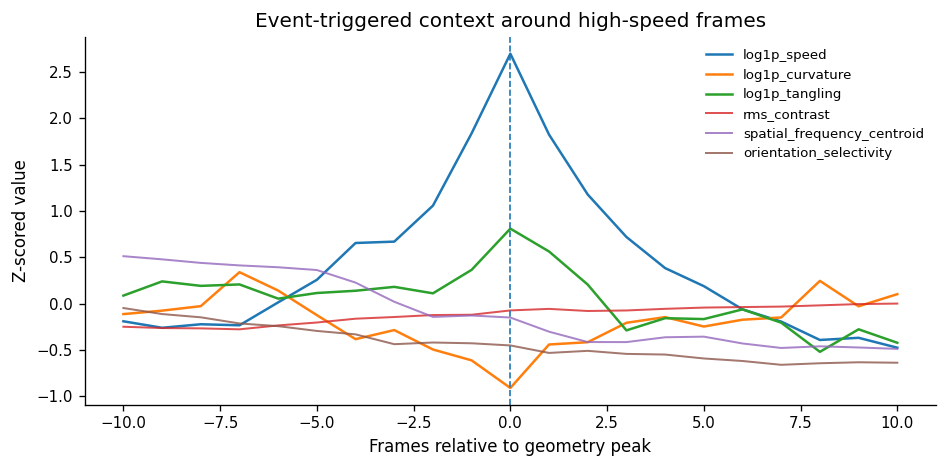

C:\Users\Peter\AppData\Local\Temp\ipykernel_12060\1361447642.py:181: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


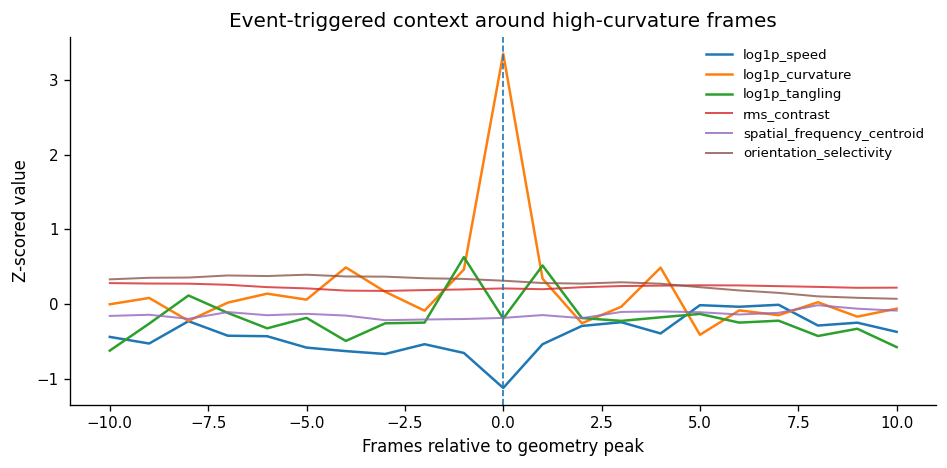

C:\Users\Peter\AppData\Local\Temp\ipykernel_12060\1361447642.py:181: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


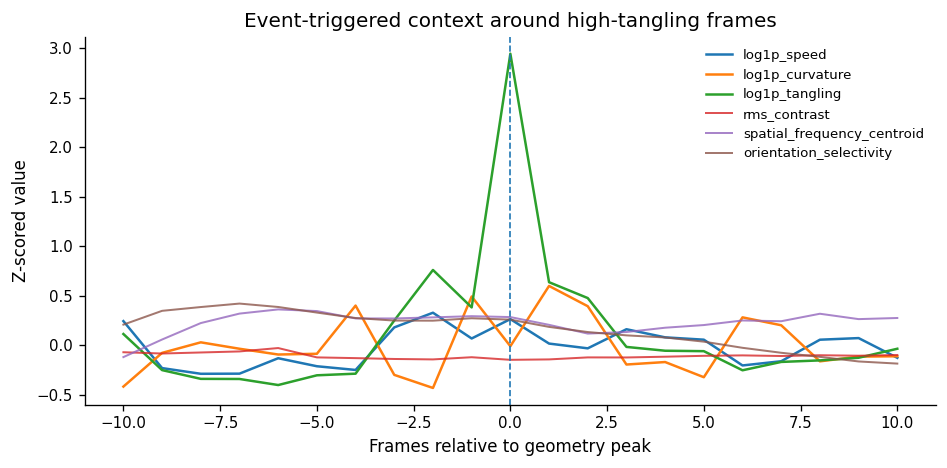

In [20]:
# ---------------------------------------------------------------------
# Event-triggered windows around geometry peaks
# ---------------------------------------------------------------------
window_radius = 10

stimulus_cols = [
    "rms_contrast",
    "spatial_frequency_centroid",
    "orientation_selectivity",
    "luminance_std",
    "total_spectral_power",
]

stimulus_cols = [c for c in stimulus_cols if c in feature_aligned.columns]

if not stimulus_cols:
    raise ValueError("No stimulus-feature columns were found in feature_aligned.")

required_objects = ["geom_ts", "feature_aligned", "top_geometry_events"]
for obj_name in required_objects:
    if obj_name not in globals():
        raise NameError(f"`{obj_name}` is not defined. Run the earlier notebook 09 cells first.")

# Make sure geometry log-transformed columns exist.
geom_ts = geom_ts.copy()

for raw_col, log_col in [
    ("speed", "log1p_speed"),
    ("curvature", "log1p_curvature"),
    ("tangling", "log1p_tangling"),
]:
    if raw_col not in geom_ts.columns:
        raise KeyError(f"`geom_ts` is missing required column: {raw_col}")

    if log_col not in geom_ts.columns:
        geom_ts[log_col] = np.log1p(np.clip(geom_ts[raw_col].to_numpy(dtype=float), a_min=0, a_max=None))

# Merge geometry and stimulus features.
context_df = geom_ts.merge(
    feature_aligned[["movie_frame"] + stimulus_cols],
    on="movie_frame",
    how="left",
)

context_df = context_df.sort_values("movie_frame").reset_index(drop=True)

# Use transformed geometry for more readable event-triggered plots.
context_cols = [
    "log1p_speed",
    "log1p_curvature",
    "log1p_tangling",
] + stimulus_cols

missing_context_cols = [c for c in context_cols if c not in context_df.columns]
if missing_context_cols:
    raise KeyError(f"Missing context columns: {missing_context_cols}")

records = []

for event_metric in ["speed", "curvature", "tangling"]:
    event_frames = (
        top_geometry_events
        .query("metric == @event_metric")["movie_frame"]
        .astype(int)
        .to_numpy()
    )

    if len(event_frames) == 0:
        print(f"No top events found for metric: {event_metric}")
        continue

    for event_frame in event_frames:
        for lag in range(-window_radius, window_radius + 1):
            frame = event_frame + lag

            if frame < 0 or frame >= len(context_df):
                continue

            row = {
                "event_metric": event_metric,
                "event_frame": int(event_frame),
                "lag": int(lag),
                "movie_frame": int(frame),
            }

            frame_row = context_df.iloc[frame]

            for col in context_cols:
                row[col] = frame_row[col]

            records.append(row)

event_triggered_context = pd.DataFrame(records)

if event_triggered_context.empty:
    raise RuntimeError(
        "No event-triggered windows were created. "
        "Check whether `top_geometry_events` contains valid movie_frame values."
    )

save_table(
    event_triggered_context,
    paths.tables_dir / f"09_event_triggered_geometry_stimulus_context_{embedding_name}_session_{session_id}.csv",
)

# Display a compact sanity check.
event_triggered_summary = (
    event_triggered_context
    .groupby("event_metric")
    .agg(
        n_events=("event_frame", "nunique"),
        n_window_rows=("movie_frame", "size"),
        min_lag=("lag", "min"),
        max_lag=("lag", "max"),
    )
    .reset_index()
)

save_table(
    event_triggered_summary,
    paths.tables_dir / f"09_event_triggered_geometry_stimulus_context_summary_{embedding_name}_session_{session_id}.csv",
)

display(event_triggered_summary)
display(event_triggered_context.head())

# Z-score columns only for plotting on a common axis.
plot_context = event_triggered_context.copy()

for col in context_cols:
    x = plot_context[col].to_numpy(dtype=float)
    mu = np.nanmean(x)
    sd = np.nanstd(x)

    if np.isfinite(sd) and sd > 0:
        plot_context[col + "_z"] = (x - mu) / sd
    else:
        plot_context[col + "_z"] = np.nan

for event_metric in ["speed", "curvature", "tangling"]:
    metric_df = plot_context.query("event_metric == @event_metric").copy()

    if metric_df.empty:
        print(f"Skipping event-triggered plot for {event_metric}: no rows.")
        continue

    plot_df = (
        metric_df
        .groupby("lag", as_index=False)
        [[c + "_z" for c in context_cols]]
        .mean()
    )

    fig, ax = plt.subplots(figsize=(8, 4))

    for col in ["log1p_speed_z", "log1p_curvature_z", "log1p_tangling_z"]:
        if col in plot_df.columns:
            ax.plot(
                plot_df["lag"],
                plot_df[col],
                linewidth=1.5,
                label=col.replace("_z", ""),
            )

    for col in [c + "_z" for c in stimulus_cols[:3]]:
        if col in plot_df.columns:
            ax.plot(
                plot_df["lag"],
                plot_df[col],
                linewidth=1.2,
                alpha=0.8,
                label=col.replace("_z", ""),
            )

    ax.axvline(0, linestyle="--", linewidth=1)
    ax.set_xlabel("Frames relative to geometry peak")
    ax.set_ylabel("Z-scored value")
    ax.set_title(f"Event-triggered context around high-{event_metric} frames")
    ax.legend(frameon=False, fontsize=8)

    fig.tight_layout()

    save_figure(
        fig,
        paths.figures_dir / f"09_event_triggered_context_high_{event_metric}_{embedding_name}.png",
    )

    plt.show()

### Geometry peak enrichment using circular-shift controls

In [21]:
# ---------------------------------------------------------------------
# Geometry peak enrichment with circular-shift nulls
# ---------------------------------------------------------------------
rng = np.random.default_rng(cfg["project"].get("random_seed", 42))

n_permutations = cfg["evaluation"].get("circular_shift_permutations", 1000)
min_shift = cfg["evaluation"].get("circular_shift_min_frames", 60)

enrichment_rows = []

for geometry_metric in ["speed", "curvature", "tangling"]:
    g = geom_ts[geometry_metric].to_numpy(dtype=float)

    finite_g = np.isfinite(g)
    threshold = np.nanpercentile(g[finite_g], 90)
    top_mask = g >= threshold

    for stimulus_feature in stimulus_cols:
        y = feature_aligned[stimulus_feature].to_numpy(dtype=float)

        valid = np.isfinite(g) & np.isfinite(y)

        if valid.sum() < 20:
            continue

        top_valid = top_mask & valid
        rest_valid = (~top_mask) & valid

        if top_valid.sum() < 5 or rest_valid.sum() < 5:
            continue

        observed_delta = float(np.nanmean(y[top_valid]) - np.nanmean(y[rest_valid]))

        null_deltas = []

        n_frames = len(top_mask)

        if n_frames > 2 * min_shift + 1:
            possible_shifts = np.arange(min_shift, n_frames - min_shift)
        else:
            possible_shifts = np.arange(1, n_frames)

        for _ in range(n_permutations):
            shift = int(rng.choice(possible_shifts))
            shifted_mask = np.roll(top_mask, shift)

            shifted_top = shifted_mask & valid
            shifted_rest = (~shifted_mask) & valid

            if shifted_top.sum() < 5 or shifted_rest.sum() < 5:
                continue

            null_deltas.append(
                float(np.nanmean(y[shifted_top]) - np.nanmean(y[shifted_rest]))
            )

        null_deltas = np.asarray(null_deltas, dtype=float)

        if len(null_deltas):
            p_shift = float(
                (np.sum(np.abs(null_deltas) >= abs(observed_delta)) + 1)
                / (len(null_deltas) + 1)
            )
            null_mean = float(np.nanmean(null_deltas))
            null_std = float(np.nanstd(null_deltas))
        else:
            p_shift = np.nan
            null_mean = np.nan
            null_std = np.nan

        enrichment_rows.append({
            "geometry_metric": geometry_metric,
            "stimulus_feature": stimulus_feature,
            "peak_definition": "top_10_percent_geometry_frames",
            "n_peak_frames": int(top_valid.sum()),
            "n_nonpeak_frames": int(rest_valid.sum()),
            "mean_peak": float(np.nanmean(y[top_valid])),
            "mean_nonpeak": float(np.nanmean(y[rest_valid])),
            "observed_delta_peak_minus_nonpeak": observed_delta,
            "circular_shift_p": p_shift,
            "null_delta_mean": null_mean,
            "null_delta_std": null_std,
            "n_permutations": int(len(null_deltas)),
            "min_shift_frames": int(min_shift),
        })

geometry_peak_enrichment = pd.DataFrame(enrichment_rows)

_save_table(
    geometry_peak_enrichment,
    paths.tables_dir / f"09_geometry_peak_feature_enrichment_{embedding_name}_session_{session_id}.csv",
)

display(
    geometry_peak_enrichment
    .assign(abs_delta=lambda d: d["observed_delta_peak_minus_nonpeak"].abs())
    .sort_values("abs_delta", ascending=False)
    .drop(columns="abs_delta")
)

,geometry_metric,stimulus_feature,peak_definition,n_peak_frames,n_nonpeak_frames,mean_peak,mean_nonpeak,observed_delta_peak_minus_nonpeak,circular_shift_p,null_delta_mean,null_delta_std,n_permutations,min_shift_frames
4,speed,total_spectral_power,top_10_percent_geometry_frames,90,810,72695.777203,84020.181488,-11324.404285,0.065934,1459.240492,6469.199939,1000,60
14,tangling,total_spectral_power,top_10_percent_geometry_frames,91,809,79165.784195,83306.403698,-4140.619503,0.416583,250.716115,5175.840487,1000,60
9,curvature,total_spectral_power,top_10_percent_geometry_frames,90,810,81242.142437,83070.585351,-1828.442914,0.574426,248.529933,3207.429920,1000,60
2,speed,orientation_selectivity,top_10_percent_geometry_frames,90,810,0.338872,0.361782,-0.022911,0.423576,0.002810,0.023561,1000,60
12,tangling,orientation_selectivity,top_10_percent_geometry_frames,91,809,0.375907,0.357644,0.018263,0.160839,-0.000858,0.013259,1000,60
7,curvature,orientation_selectivity,top_10_percent_geometry_frames,90,810,0.365218,0.358855,0.006363,0.435564,-0.000164,0.007862,1000,60
5,curvature,rms_contrast,top_10_percent_geometry_frames,90,810,0.375802,0.377942,-0.002139,0.342657,0.000127,0.002179,1000,60
8,curvature,luminance_std,top_10_percent_geometry_frames,90,810,0.185007,0.186160,-0.001153,0.340659,0.000055,0.001165,1000,60
11,tangling,spatial_frequency_centroid,top_10_percent_geometry_frames,91,809,0.233608,0.234598,-0.000991,0.607393,0.000092,0.001838,1000,60
6,curvature,spatial_frequency_centroid,top_10_percent_geometry_frames,90,810,0.234083,0.234544,-0.000461,0.748252,0.000170,0.001447,1000,60


### Optional: show actual natural movie frames at geometry peaks

c:\Users\Peter\.neuro\Lib\site-packages\allensdk\core\brain_observatory_nwb_data_set.py:43: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


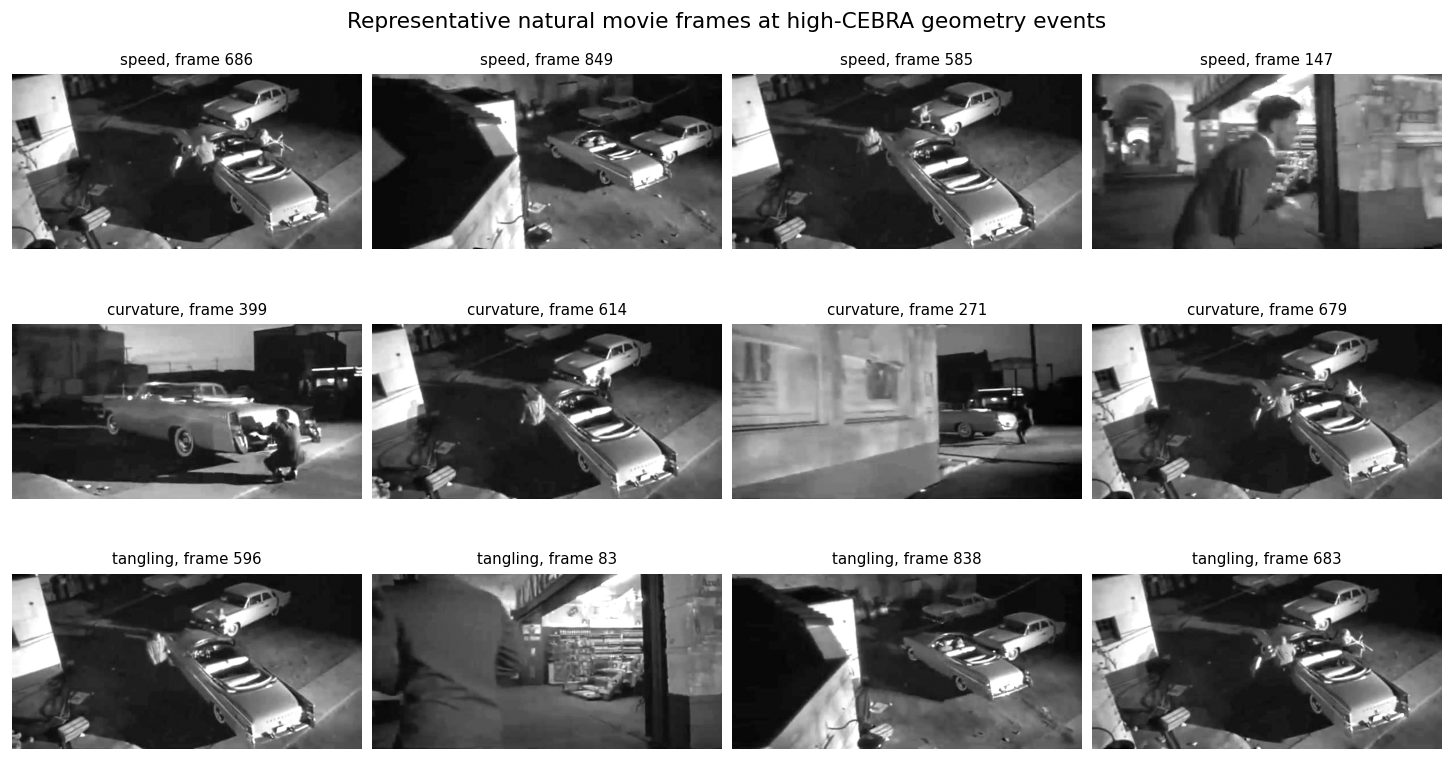

In [22]:
# ---------------------------------------------------------------------
# Optional movie-frame montage for top geometry events
# ---------------------------------------------------------------------
def _load_natural_movie_template_safely():
    if "movie" in globals():
        return np.asarray(movie)

    try:
        from v1_manifold.data_access import get_boc, get_experiment_data, get_stimulus_template

        boc = get_boc(paths.allen_manifest)
        data_set = get_experiment_data(boc, int(session_id))
        movie_template = get_stimulus_template(
            data_set,
            cfg["preprocessing"]["stimulus_name"],
        )
        return np.asarray(movie_template)

    except Exception as exc:
        print("Could not load natural movie template.")
        print("Reason:", repr(exc))
        return None


def _diverse_top_frames(event_table, metric, n_frames=4, min_gap=40):
    ranked = (
        event_table
        .query("metric == @metric")
        .sort_values("value", ascending=False)["movie_frame"]
        .astype(int)
        .to_list()
    )

    selected = []

    for frame in ranked:
        if all(abs(frame - prev) >= min_gap for prev in selected):
            selected.append(frame)

        if len(selected) == n_frames:
            break

    # Fill with remaining top frames if the diversity rule is too strict.
    for frame in ranked:
        if frame not in selected:
            selected.append(frame)

        if len(selected) == n_frames:
            break

    return selected


movie_template = _load_natural_movie_template_safely()

if movie_template is not None:
    metrics = ["speed", "curvature", "tangling"]
    n_cols = 4

    fig, axes = plt.subplots(
        len(metrics),
        n_cols,
        figsize=(12, 6.5),
        constrained_layout=True,
    )

    for row_idx, metric in enumerate(metrics):
        frames = _diverse_top_frames(
            top_geometry_events,
            metric=metric,
            n_frames=n_cols,
            min_gap=40,
        )

        for col_idx in range(n_cols):
            ax = axes[row_idx, col_idx]
            frame = frames[col_idx]

            if 0 <= frame < len(movie_template):
                ax.imshow(movie_template[frame], cmap="gray")
                ax.set_title(f"{metric}, frame {frame}", fontsize=9)
            else:
                ax.set_title(f"{metric}, frame {frame}\nnot available", fontsize=9)

            ax.axis("off")

    fig.suptitle(
        f"Representative natural movie frames at high-{embedding_name.upper()} geometry events",
        fontsize=13,
    )

    _save_figure(
        fig,
        paths.figures_dir / f"09_movie_frames_at_top_geometry_events_{embedding_name}.png",
    )

    plt.show()
else:
    print("Skipping movie-frame montage because the movie template was not available.")

In [23]:
# ---------------------------------------------------------------------
# Save provisional interpretation notes
# ---------------------------------------------------------------------
notes = []

notes.append(f"# Notebook 09 interpretability notes — session {session_id}\n")
notes.append(f"Primary embedding inspected: `{embedding_name}`.\n")

notes.append("## Geometry distribution\n")
for _, row in geometry_distribution_summary.iterrows():
    notes.append(
        f"- `{row['metric']}`: median = {row['median']:.4g}, "
        f"p99 = {row['p99']:.4g}, max = {row['max']:.4g}."
    )

if "geometry_stimulus_alignment" in globals() and not geometry_stimulus_alignment.empty:
    max_assoc = (
        geometry_stimulus_alignment
        .assign(abs_r=lambda d: d["spearman_r"].abs())
        .sort_values("abs_r", ascending=False)
        .iloc[0]
    )

    notes.append("\n## Geometry–stimulus association\n")
    notes.append(
        f"- Strongest absolute Spearman association: "
        f"`{max_assoc['geometry_metric']}` vs `{max_assoc['stimulus_feature']}`, "
        f"r = {max_assoc['spearman_r']:.3f}."
    )
    notes.append(
        "- These associations should be interpreted as descriptive, not causal, "
        "because movie frames are temporally autocorrelated."
    )

if "geometry_peak_enrichment" in globals() and not geometry_peak_enrichment.empty:
    best_peak = (
        geometry_peak_enrichment
        .assign(abs_delta=lambda d: d["observed_delta_peak_minus_nonpeak"].abs())
        .sort_values("abs_delta", ascending=False)
        .iloc[0]
    )

    notes.append("\n## Geometry peak enrichment\n")
    notes.append(
        f"- Largest peak/non-peak stimulus difference: "
        f"`{best_peak['geometry_metric']}` peaks vs `{best_peak['stimulus_feature']}`, "
        f"delta = {best_peak['observed_delta_peak_minus_nonpeak']:.4g}, "
        f"circular-shift p = {best_peak['circular_shift_p']:.4g}."
    )

notes.append("\n## Working interpretation\n")
notes.append(
    "- Large geometry spikes likely mark abrupt changes or local discontinuities in the learned neural trajectory. "
    "Because curvature and tangling have heavy-tailed distributions, robust summaries and clipped visualisations "
    "are more reliable than raw maximum values alone."
)
notes.append(
    "- The key manuscript-level question is whether these geometry events align with interpretable movie features "
    "or instead reflect internal population-state transitions not captured by the current low-level visual descriptors."
)

notes_text = "\n".join(notes)

notes_path = paths.tables_dir / f"09_interpretability_notes_{embedding_name}_session_{session_id}.md"
notes_path.parent.mkdir(parents=True, exist_ok=True)
notes_path.write_text(notes_text, encoding="utf-8")

print(f"Saved interpretation notes: {notes_path}")
print(notes_text)

Saved interpretation notes: C:\Users\Peter\Documents\projects\NeuroAI\latent-manifold-v1-natural-movies\reports\tables\09_interpretability_notes_cebra_session_500855614.md
# Notebook 09 interpretability notes — session 500855614

Primary embedding inspected: `cebra`.

## Geometry distribution

- `speed`: median = 0.09065, p99 = 0.5313, max = 0.8131.
- `curvature`: median = 3.959, p99 = 443.5, max = 4.127e+04.
- `tangling`: median = 13.68, p99 = 816.9, max = 6.342e+04.

## Geometry–stimulus association

- Strongest absolute Spearman association: `log1p_speed` vs `total_spectral_power`, r = -0.152.
- These associations should be interpreted as descriptive, not causal, because movie frames are temporally autocorrelated.

## Geometry peak enrichment

- Largest peak/non-peak stimulus difference: `speed` peaks vs `total_spectral_power`, delta = -1.132e+04, circular-shift p = 0.06593.

## Working interpretation

- Large geometry spikes likely mark abrupt changes or local discontinuities in th

In [24]:
# ---------------------------------------------------------------------
# Persistent homology of the selected low-dimensional embedding
# ---------------------------------------------------------------------
# This is optional/supplementary. It asks whether the latent trajectory has
# coarse topological structure such as connected components, loops, or voids.

try:
    ph = persistent_homology(
        Z,
        maxdim=2,
        subsample=min(900, Z.shape[0]),
        seed=cfg["project"]["random_seed"],
    )

    diagrams = ph["dgms"]
    rows = []

    for dim, diagram in enumerate(diagrams):
        diagram = np.asarray(diagram)

        if diagram.size == 0:
            rows.append({
                "embedding": embedding_name,
                "homology_dim": dim,
                "n_features": 0,
                "n_finite_features": 0,
                "max_finite_lifetime": 0.0,
                "mean_finite_lifetime": 0.0,
                "median_finite_lifetime": 0.0,
            })
            continue

        finite_mask = np.isfinite(diagram[:, 1])
        finite = diagram[finite_mask]

        if len(finite):
            lifetimes = finite[:, 1] - finite[:, 0]
            max_lifetime = float(np.max(lifetimes))
            mean_lifetime = float(np.mean(lifetimes))
            median_lifetime = float(np.median(lifetimes))
        else:
            max_lifetime = 0.0
            mean_lifetime = 0.0
            median_lifetime = 0.0

        rows.append({
            "embedding": embedding_name,
            "homology_dim": dim,
            "n_features": int(len(diagram)),
            "n_finite_features": int(finite_mask.sum()),
            "max_finite_lifetime": max_lifetime,
            "mean_finite_lifetime": mean_lifetime,
            "median_finite_lifetime": median_lifetime,
        })

    ph_summary = pd.DataFrame(rows)

    save_table(
        ph_summary,
        paths.tables_dir / f"09_persistent_homology_summary_{embedding_name}_session_{session_id}.csv",
    )

    display(ph_summary)

    # Plot only finite persistence points. Infinite H0 deaths can distort the figure.
    fig, ax = plt.subplots(figsize=(5, 5))

    for dim, diagram in enumerate(diagrams):
        diagram = np.asarray(diagram)

        if diagram.size == 0:
            continue

        finite = diagram[np.isfinite(diagram[:, 1])]

        if len(finite):
            ax.scatter(
                finite[:, 0],
                finite[:, 1],
                s=18,
                label=f"H{dim}",
                alpha=0.8,
            )

    # Add diagonal reference line.
    all_finite = [
        np.asarray(dgm)[np.isfinite(np.asarray(dgm)[:, 1])]
        for dgm in diagrams
        if np.asarray(dgm).size > 0
    ]

    all_finite = [dgm for dgm in all_finite if len(dgm)]

    if all_finite:
        stacked = np.vstack(all_finite)
        lo = float(np.nanmin(stacked))
        hi = float(np.nanmax(stacked))

        ax.plot([lo, hi], [lo, hi], linestyle="--", linewidth=1)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    ax.set_xlabel("Birth")
    ax.set_ylabel("Death")
    ax.set_title(f"{embedding_name.upper()} persistence diagram")
    ax.legend(frameon=False)

    fig.tight_layout()

    save_figure(
        fig,
        paths.figures_dir / f"09_persistence_diagram_{embedding_name}.png",
    )

    plt.show()

except ImportError as exc:
    print("Persistent homology package is not installed.")
    print(exc)

except Exception as exc:
    print("Persistent homology failed.")
    print("This does not invalidate the previous notebook 09 analyses.")
    print("Reason:", repr(exc))

: 